In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

pd.options.display.float_format = '{:,.2f}'.format
register_matplotlib_converters()

data = pd.read_csv('cost_revenue_dirty.csv')

print(f'Shape : {data.shape}')
data.head()

Shape : (5391, 6)


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,"$110,000","$11,000,000","$10,000,000"
1,5140,5/9/1916,Intolerance,"$385,907",$0,$0
2,5230,12/24/1916,"20,000 Leagues Under the Sea","$200,000","$8,000,000","$8,000,000"
3,5299,9/17/1920,Over the Hill to the Poorhouse,"$100,000","$3,000,000","$3,000,000"
4,5222,1/1/1925,The Big Parade,"$245,000","$22,000,000","$11,000,000"


In [2]:
print(f'NaN values : {data.isna().values.any()}')
print(f'Duplicates? : {data.duplicated().values.any()}')

duplicated_rows = data[data.duplicated()]
print(f'Total Duplicates : {len(duplicated_rows)}')

NaN values : False
Duplicates? : False
Total Duplicates : 0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Rank                   5391 non-null   int64 
 1   Release_Date           5391 non-null   object
 2   Movie_Title            5391 non-null   object
 3   USD_Production_Budget  5391 non-null   object
 4   USD_Worldwide_Gross    5391 non-null   object
 5   USD_Domestic_Gross     5391 non-null   object
dtypes: int64(1), object(5)
memory usage: 252.8+ KB


In [4]:
chars_to_remove = [',', '$']
columns_to_clean = ['USD_Production_Budget', 'USD_Worldwide_Gross', 'USD_Domestic_Gross']

for col in columns_to_clean:
    for char in chars_to_remove:
        data[col] = data[col].astype(str).str.replace(char, "")
    data[col] = pd.to_numeric(data[col])

data.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,8/2/1915,The Birth of a Nation,110000,11000000,10000000
1,5140,5/9/1916,Intolerance,385907,0,0
2,5230,12/24/1916,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,9/17/1920,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1/1/1925,The Big Parade,245000,22000000,11000000


In [5]:
data.Release_Date = pd.to_datetime(data.Release_Date)
data.head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
0,5293,1915-08-02,The Birth of a Nation,110000,11000000,10000000
1,5140,1916-05-09,Intolerance,385907,0,0
2,5230,1916-12-24,"20,000 Leagues Under the Sea",200000,8000000,8000000
3,5299,1920-09-17,Over the Hill to the Poorhouse,100000,3000000,3000000
4,5222,1925-01-01,The Big Parade,245000,22000000,11000000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5391 entries, 0 to 5390
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Rank                   5391 non-null   int64         
 1   Release_Date           5391 non-null   datetime64[ns]
 2   Movie_Title            5391 non-null   object        
 3   USD_Production_Budget  5391 non-null   int64         
 4   USD_Worldwide_Gross    5391 non-null   int64         
 5   USD_Domestic_Gross     5391 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 252.8+ KB


In [7]:
data[data.USD_Production_Budget == 1100.00]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
2427,5391,2005-05-08,My Date With Drew,1100,181041,181041


In [8]:
data[data.USD_Production_Budget == 425000000.00]

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
3529,1,2009-12-18,Avatar,425000000,2783918982,760507625


In [9]:
zero_domestic = data[data.USD_Domestic_Gross == 0]

print(f'Total films with domestic gross of $0 : {len(zero_domestic)}')
zero_domestic.sort_values('USD_Production_Budget', ascending=False)

Total films with domestic gross of $0 : 512


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5090,556,2015-12-31,"Don Gato, el inicio de la pandilla",80000000,4547660,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


In [10]:
zero_worldwide = data[data.USD_Worldwide_Gross == 0]

print(f'Total films with worldwide gross of $0 : {len(zero_worldwide)}')
zero_worldwide.sort_values('USD_Production_Budget', ascending=False)

Total films with worldwide gross of $0 : 357


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5388,96,2020-12-31,Singularity,175000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5058,880,2015-11-12,The Ridiculous 6,60000000,0,0
...,...,...,...,...,...,...
4787,5371,2014-12-31,Stories of Our Lives,15000,0,0
3056,5374,2007-12-31,Tin Can Man,12000,0,0
4907,5381,2015-05-19,Family Motocross,10000,0,0
5006,5389,2015-09-29,Signed Sealed Delivered,5000,0,0


In [11]:
international_releases = data.loc[(data.USD_Domestic_Gross == 0) & (data.USD_Worldwide_Gross != 0)]

print(f'Total International releases : {len(international_releases)}')
international_releases.head()

Total International releases : 155


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
71,4310,1956-02-16,Carousel,3380000,3220,0
1579,5087,2001-02-11,Everything Put Together,500000,7890,0
1744,3695,2001-12-31,The Hole,7500000,10834406,0
2155,4236,2003-12-31,Nothing,4000000,63180,0
2203,2513,2004-03-31,The Touch,20000000,5918742,0


In [12]:
international_releases = data.query('USD_Domestic_Gross == 0 and USD_Worldwide_Gross != 0')

print(f'Total Intertional releases : {len(international_releases)}')
international_releases.tail()

Total Intertional releases : 155


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5340,1506,2017-04-14,Queen of the Desert,36000000,1480089,0
5348,2225,2017-05-05,Chāi dàn zhuānjiā,23000000,58807172,0
5360,4832,2017-07-03,Departure,1100000,27561,0
5372,1856,2017-08-25,Ballerina,30000000,48048527,0
5374,4237,2017-08-25,Polina danser sa vie,4000000,36630,0


In [13]:
scrape_data = pd.Timestamp('2018-5-1')
future_releases = data[data.Release_Date >= scrape_data]

print(f'Total unreleased movies : {len(future_releases)}')
future_releases

Total unreleased movies : 7


,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross
5384,321,2018-09-03,A Wrinkle in Time,103000000,0,0
5385,366,2018-10-08,Amusement Park,100000000,0,0
5386,2950,2018-10-08,Meg,15000000,0,0
5387,126,2018-12-18,Aquaman,160000000,0,0
5388,96,2020-12-31,Singularity,175000000,0,0
5389,1119,2020-12-31,Hannibal the Conqueror,50000000,0,0
5390,2517,2020-12-31,"Story of Bonnie and Clyde, The",20000000,0,0


In [14]:
data_clean = data.drop(future_releases.index)

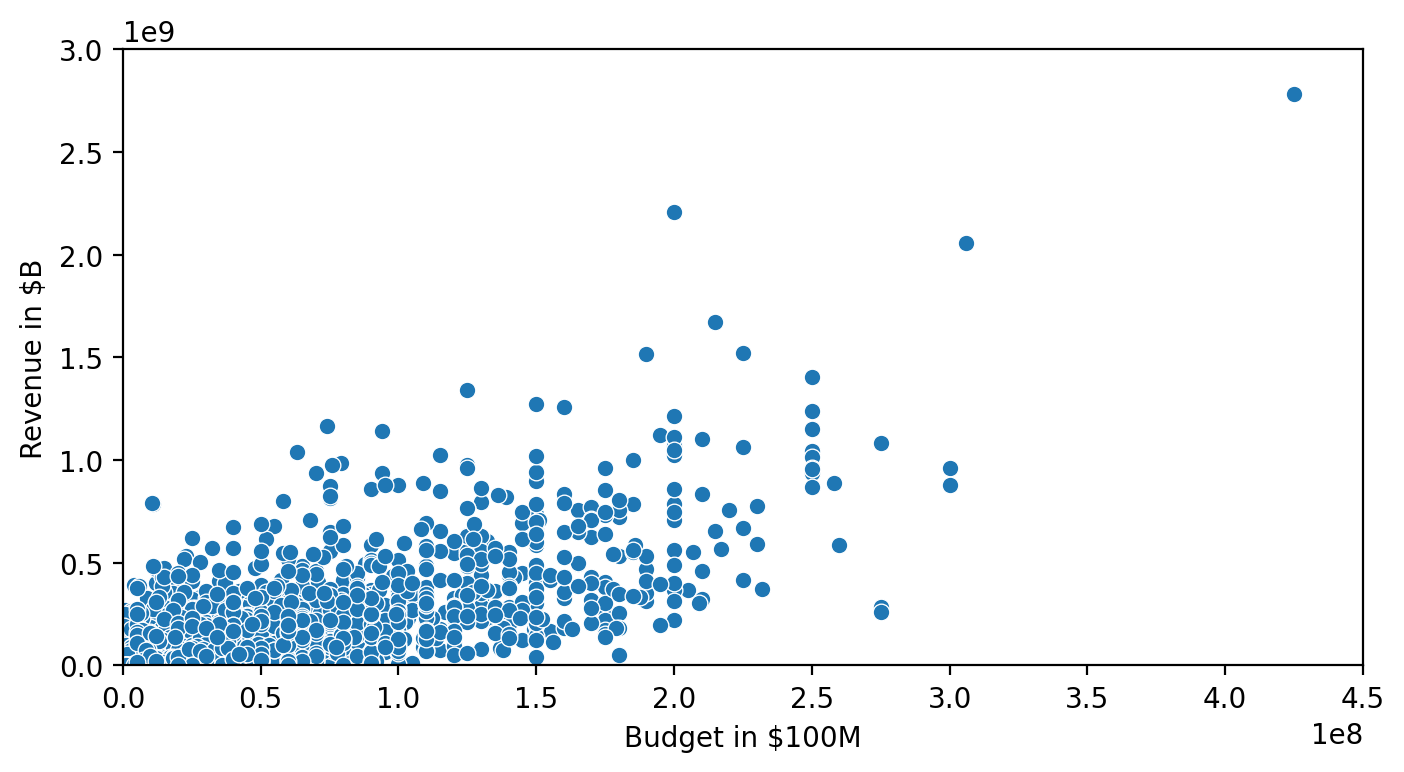

In [15]:
import seaborn as sns

plt.figure(figsize=(8, 4), dpi=200)

ax = sns.scatterplot(data = data_clean, x = 'USD_Production_Budget', y = 'USD_Worldwide_Gross')

ax.set(ylim = (0, 3000000000), xlim = (0, 450000000), ylabel = 'Revenue in $B', xlabel = 'Budget in $100M')

plt.show()

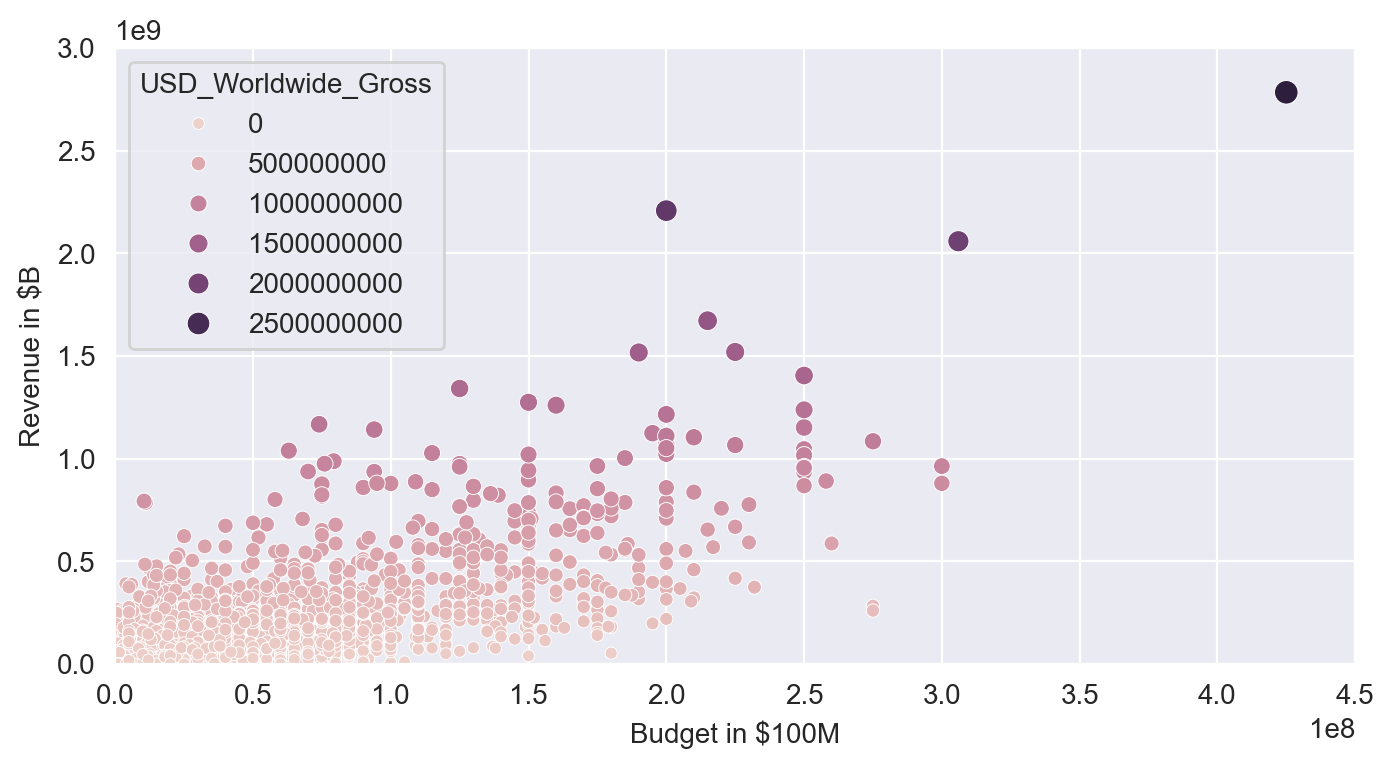

In [16]:
plt.figure(figsize=(8, 4), dpi=200)

with sns.axes_style('darkgrid'):
    ax = sns.scatterplot(data = data_clean, x = 'USD_Production_Budget', y = 'USD_Worldwide_Gross', hue = 'USD_Worldwide_Gross', size = 'USD_Worldwide_Gross')

    ax.set(ylim = (0, 3000000000), xlim = (0, 450000000), ylabel = 'Revenue in $B', xlabel = 'Budget in $100M')

    plt.show()

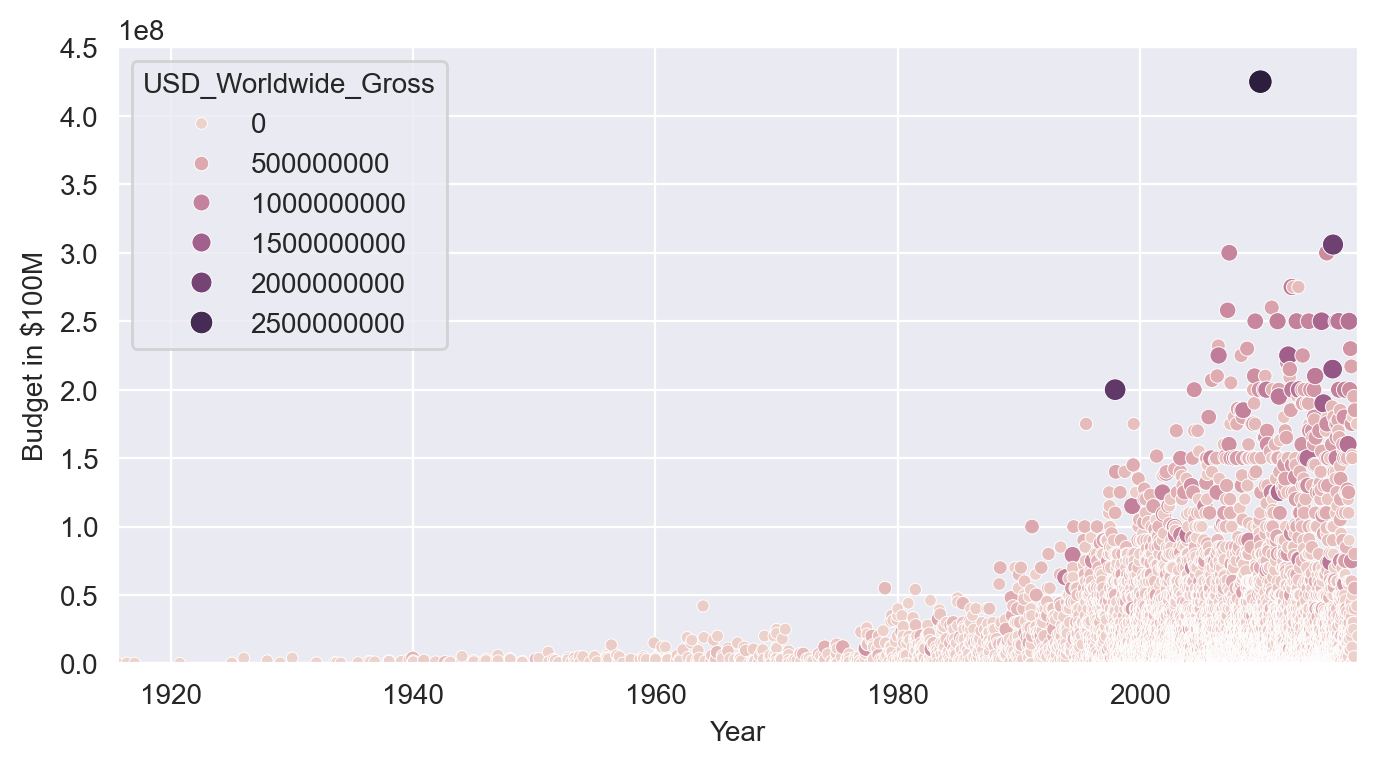

In [17]:
plt.figure(figsize=(8, 4), dpi=200)

with sns.axes_style('darkgrid'):
    ax = sns.scatterplot(data = data_clean, x = 'Release_Date', y = 'USD_Production_Budget', hue = 'USD_Worldwide_Gross', size = 'USD_Worldwide_Gross')

    ax.set(ylim = (0, 450000000), xlim = (data_clean.Release_Date.min(), data_clean.Release_Date.max()), ylabel = 'Budget in $100M', xlabel = 'Year')

    plt.show()

In [18]:
dt_index = pd.DatetimeIndex(data_clean.Release_Date)
years = dt_index.year

decades = years // 10 * 10
data_clean['Decade'] = decades

In [19]:
old_films = data_clean[data_clean.Decade <= 1960]
new_films = data_clean[data_clean.Decade > 1960]

In [20]:
old_films.sort_values('USD_Production_Budget', ascending=False).head()

,Rank,Release_Date,Movie_Title,USD_Production_Budget,USD_Worldwide_Gross,USD_Domestic_Gross,Decade
109,1253,1963-12-06,Cleopatra,42000000,71000000,57000000,1960
150,2175,1969-12-16,"Hello, Dolly",24000000,33208099,33208099,1960
118,2425,1965-02-15,The Greatest Story Ever Told,20000000,15473333,15473333,1960
143,2465,1969-01-01,Sweet Charity,20000000,8000000,8000000,1960
148,2375,1969-10-15,Paint Your Wagon,20000000,31678778,31678778,1960


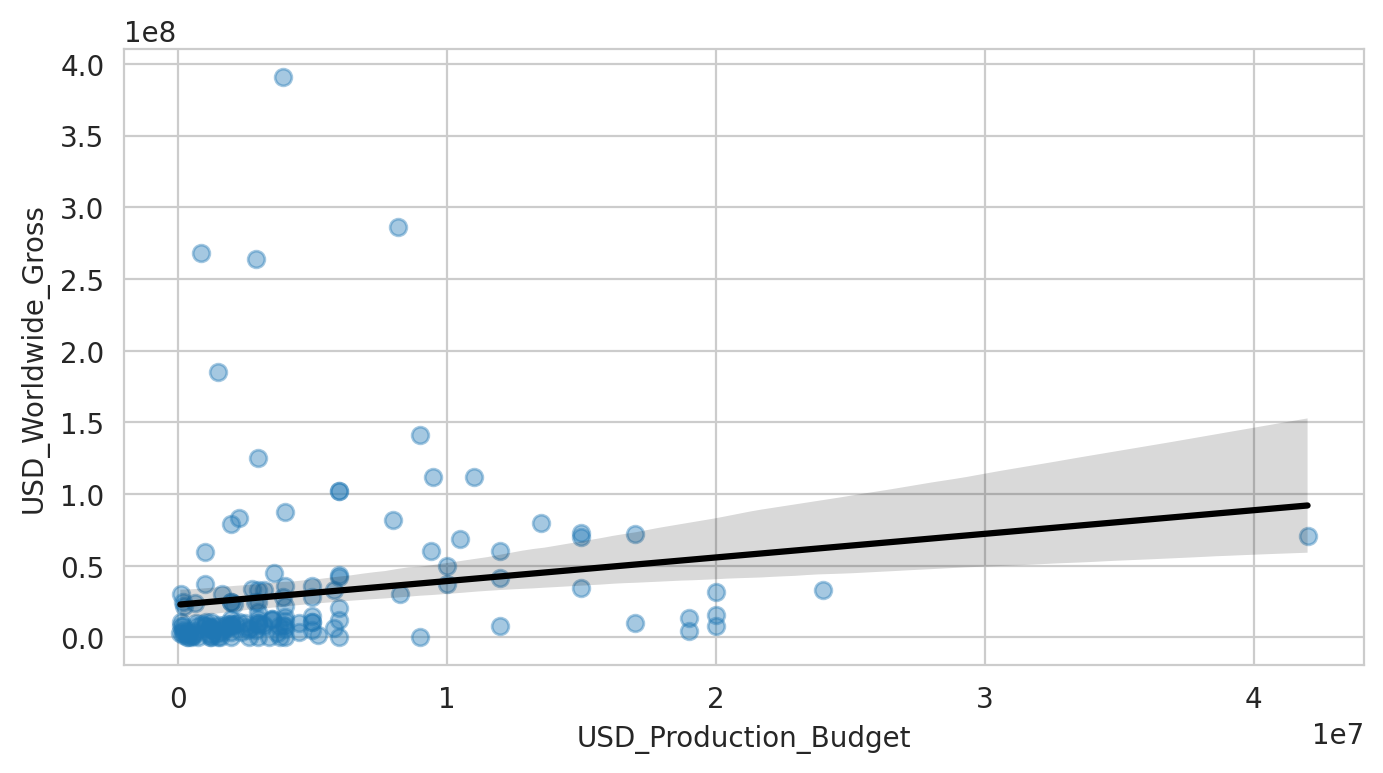

In [21]:
plt.figure(figsize=(8, 4), dpi=200)

with sns.axes_style('whitegrid'):
    sns.regplot(data = old_films, x = 'USD_Production_Budget', y = 'USD_Worldwide_Gross', scatter_kws = {'alpha': 0.4}, line_kws = {'color': 'black'})

plt.show()


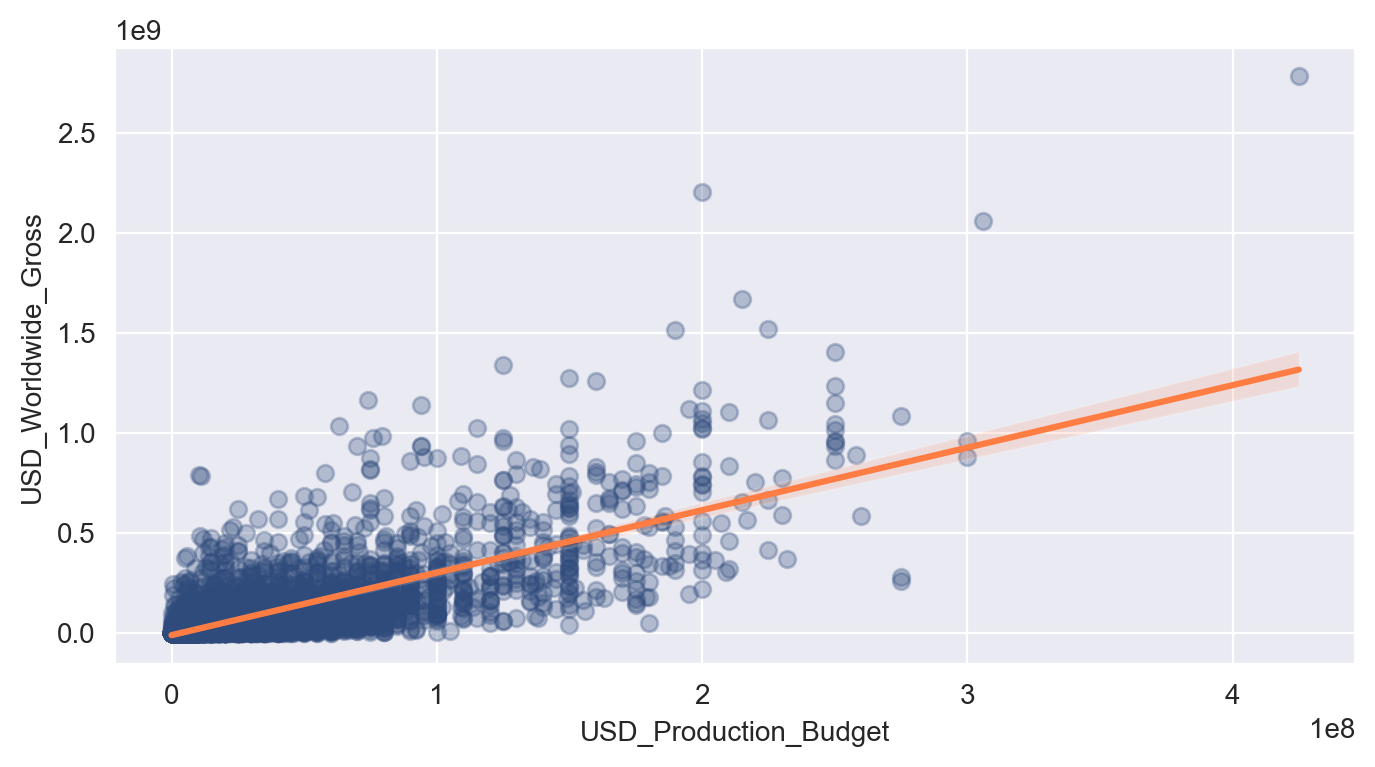

In [22]:
plt.figure(figsize=(8, 4), dpi=200)

with sns.axes_style('darkgrid'):
    sns.regplot(data = new_films, x = 'USD_Production_Budget', y = 'USD_Worldwide_Gross', color = '#2f4b7c', scatter_kws = {'alpha': 0.3}, line_kws = {'color': '#ff7c43'})

    ax.set(ylim = (0, 3000000000), xlim = (0, 450000000), ylabel = 'Revenue in $B', xlabel = 'Budget in $100M')

    plt.show()

#### ***Linear Regression***

With the use of data on budgets, linear regression estimates the best possible line to fit the movie revenues. The regression line follows the structure :

$$
\text{REVENUE} = \underbrace{\theta_0}_{\text{y-intercept}} + \underbrace{\theta_1}_{\text{slope}} \times \text{BUDGET}
$$

In [23]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

x = pd.DataFrame(new_films, columns = ['USD_Production_Budget'])
y = pd.DataFrame(new_films, columns = ['USD_Worldwide_Gross'])

regression.fit(x, y)

print(f'y-intercept : {regression.intercept_}')
print(f'slope : {regression.coef_}')

y-intercept : [-8650768.00661042]
slope : [[3.12259592]]


In [24]:
print(f'R Squared (Goodness of Fit) : {regression.score(x, y)}')

R Squared (Goodness of Fit) : 0.5577032617720403


In [25]:
x = pd.DataFrame(old_films, columns = ['USD_Production_Budget'])
y = pd.DataFrame(old_films, columns = ['USD_Worldwide_Gross'])

regression.fit(x, y)

print(f'y-intercept : {regression.intercept_}')
print(f'slope : {regression.coef_}')
print(f'R Squared (A Bad Fit) : {regression.score(x, y)}')

budget = 350000000
revenue_estimate = regression.intercept_[0] + regression.coef_[0, 0] * budget

revenue_estimate = round(revenue_estimate, -6)
print(f'The estimated revenue for a $350M film : ${revenue_estimate:.10}')

y-intercept : [22821538.63508039]
slope : [[1.64771314]]
R Squared (A Bad Fit) : 0.02937258620576877
The estimated revenue for a $350M film : $600000000.0
